In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [3]:
data = {
    'Order_ID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Product': ['Laptop', 'Mouse', 'Keyboard', 'Monitor', 'Laptop',
                'Mouse', 'Chair', np.nan, 'Monitor', 'Keyboard'],
    'Category': ['Electronics', 'Accessories', 'Accessories', 'Electronics', 'Electronics',
                 'Accessories', 'Furniture', 'Furniture', 'Electronics', 'Accessories'],
    'Region': ['North', 'South', 'North', 'West', 'South',
               'North', 'West', 'South', 'North', 'West'],
    'Price': [55000, 500, 1200, 15000, 58000, 450, 3500, np.nan, 14500, 1100],
    'Quantity': [1, 3, 2, 1, 1, 5, 2, 1, 2, 4],
    'Order_Date': ['2026-01-05', '2026-01-06', '2026-01-10', '2026-02-01', '2026-02-15',
                   '2026-02-20', '2026-03-01', '2026-03-05', '2026-03-10', '2026-03-15']
}
df = pd.DataFrame(data)

In [4]:
df

,Order_ID,Product,Category,Region,Price,Quantity,Order_Date
0,101,Laptop,Electronics,North,55000.0,1,2026-01-05
1,102,Mouse,Accessories,South,500.0,3,2026-01-06
2,103,Keyboard,Accessories,North,1200.0,2,2026-01-10
3,104,Monitor,Electronics,West,15000.0,1,2026-02-01
4,105,Laptop,Electronics,South,58000.0,1,2026-02-15
5,106,Mouse,Accessories,North,450.0,5,2026-02-20
6,107,Chair,Furniture,West,3500.0,2,2026-03-01
7,108,NaN,Furniture,South,NaN,1,2026-03-05
8,109,Monitor,Electronics,North,14500.0,2,2026-03-10
9,110,Keyboard,Accessories,West,1100.0,4,2026-03-15


In [5]:
#problem 1
df.info()
print("missing values",df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order_ID    10 non-null     int64  
 1   Product     9 non-null      str    
 2   Category    10 non-null     str    
 3   Region      10 non-null     str    
 4   Price       9 non-null      float64
 5   Quantity    10 non-null     int64  
 6   Order_Date  10 non-null     str    
dtypes: float64(1), int64(2), str(4)
memory usage: 692.0 bytes
missing values Order_ID      0
Product       1
Category      0
Region        0
Price         1
Quantity      0
Order_Date    0
dtype: int64


In [6]:
# problem two
df["Order_Date"]=pd.to_datetime(df["Order_Date"])

In [7]:
df["Order_Date"]

0   2026-01-05
1   2026-01-06
2   2026-01-10
3   2026-02-01
4   2026-02-15
5   2026-02-20
6   2026-03-01
7   2026-03-05
8   2026-03-10
9   2026-03-15
Name: Order_Date, dtype: datetime64[us]

In [8]:
#problem 3
df["Product"]=df["Product"].fillna('unknown')

In [9]:
df["Product"]

0      Laptop
1       Mouse
2    Keyboard
3     Monitor
4      Laptop
5       Mouse
6       Chair
7     unknown
8     Monitor
9    Keyboard
Name: Product, dtype: str

In [10]:
df["Product"].info()

<class 'pandas.Series'>
RangeIndex: 10 entries, 0 to 9
Series name: Product
Non-Null Count  Dtype
--------------  -----
10 non-null     str  
dtypes: str(1)
memory usage: 212.0 bytes


In [11]:
df["Price"]=df["Price"].fillna(df.groupby('Category')["Price"].transform('mean'))
df["Price"]

0    55000.0
1      500.0
2     1200.0
3    15000.0
4    58000.0
5      450.0
6     3500.0
7     3500.0
8    14500.0
9     1100.0
Name: Price, dtype: float64

In [12]:
df["Total_salses"]=df["Price"] * df["Quantity"]

In [13]:
df


,Order_ID,Product,Category,Region,Price,Quantity,Order_Date,Total_salses
0,101,Laptop,Electronics,North,55000.0,1,2026-01-05,55000.0
1,102,Mouse,Accessories,South,500.0,3,2026-01-06,1500.0
2,103,Keyboard,Accessories,North,1200.0,2,2026-01-10,2400.0
3,104,Monitor,Electronics,West,15000.0,1,2026-02-01,15000.0
4,105,Laptop,Electronics,South,58000.0,1,2026-02-15,58000.0
5,106,Mouse,Accessories,North,450.0,5,2026-02-20,2250.0
6,107,Chair,Furniture,West,3500.0,2,2026-03-01,7000.0
7,108,unknown,Furniture,South,3500.0,1,2026-03-05,3500.0
8,109,Monitor,Electronics,North,14500.0,2,2026-03-10,29000.0
9,110,Keyboard,Accessories,West,1100.0,4,2026-03-15,4400.0


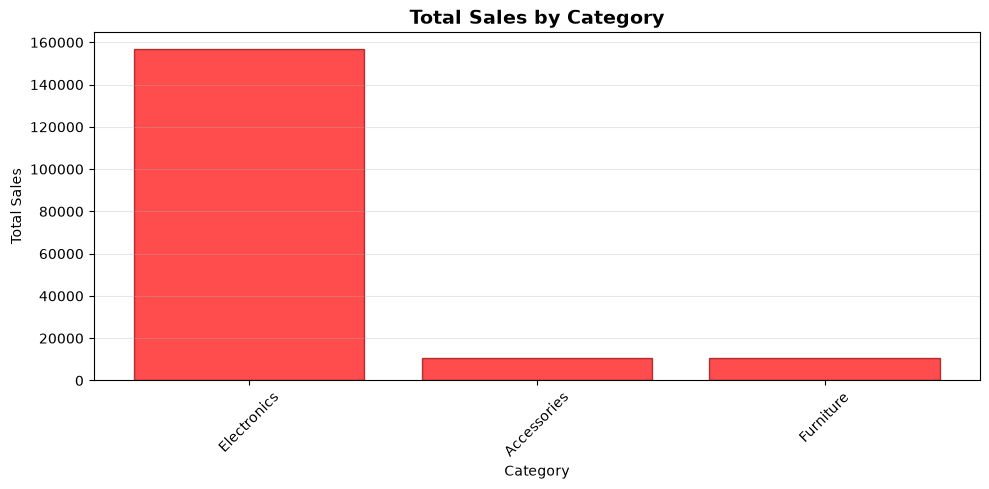

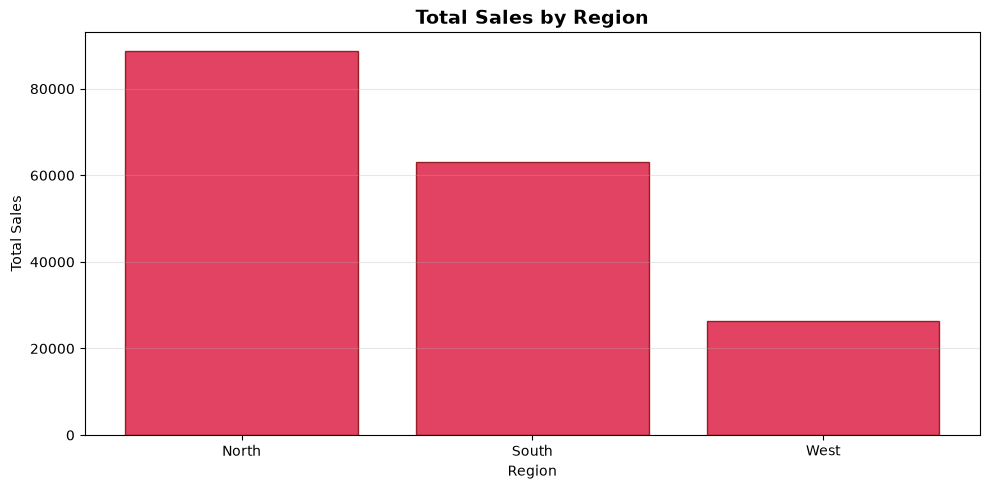

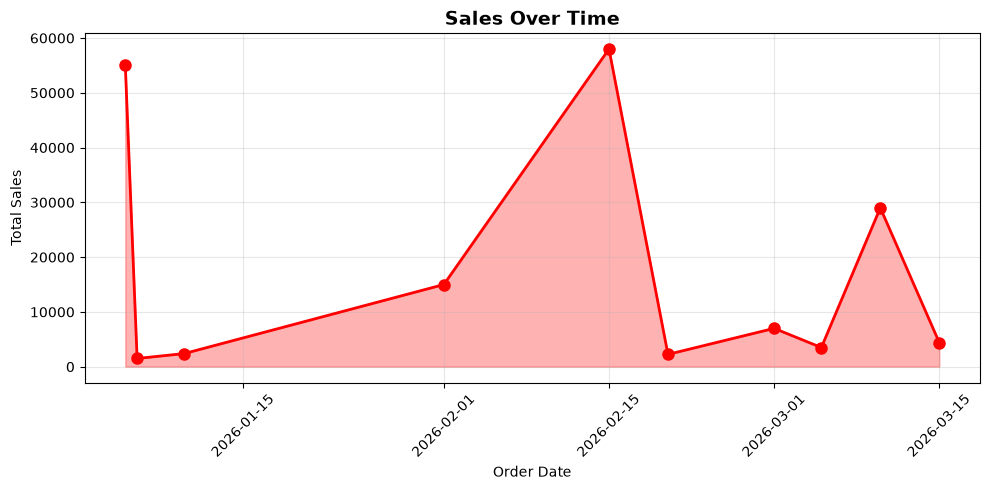

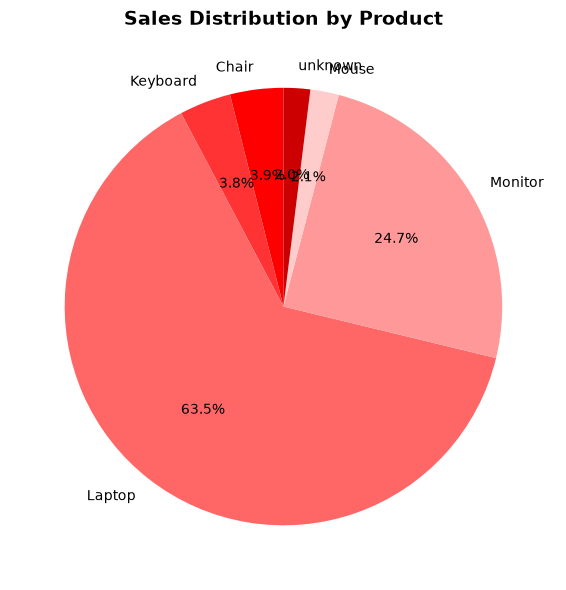

In [14]:
# Visualizations in Red Color

# 1. Total Sales by Category
plt.figure(figsize=(10, 5))
category_sales = df.groupby('Category')['Total_salses'].sum().sort_values(ascending=False)
plt.bar(category_sales.index, category_sales.values, color='red', alpha=0.7, edgecolor='darkred')
plt.title('Total Sales by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Total Sales by Region
plt.figure(figsize=(10, 5))
region_sales = df.groupby('Region')['Total_salses'].sum().sort_values(ascending=False)
plt.bar(region_sales.index, region_sales.values, color='crimson', alpha=0.8, edgecolor='maroon')
plt.title('Total Sales by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Sales Over Time
plt.figure(figsize=(10, 5))
daily_sales = df.groupby('Order_Date')['Total_salses'].sum()
plt.plot(daily_sales.index, daily_sales.values, color='red', marker='o', linewidth=2, markersize=8)
plt.fill_between(daily_sales.index, daily_sales.values, alpha=0.3, color='red')
plt.title('Sales Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Product Distribution (Pie Chart)
plt.figure(figsize=(8, 6))
product_sales = df.groupby('Product')['Total_salses'].sum()
colors = ['#ff0000', '#ff3333', '#ff6666', '#ff9999', '#ffcccc', '#cc0000']
plt.pie(product_sales.values, labels=product_sales.index, autopct='%1.1f%%', 
        colors=colors, startangle=90, textprops={'fontsize': 10})
plt.title('Sales Distribution by Product', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
print(df[(df["Region"]=="North") & (df["Total_salses"]>5000)])

   Order_ID  Product     Category Region    Price  Quantity Order_Date  \
0       101   Laptop  Electronics  North  55000.0         1 2026-01-05   
8       109  Monitor  Electronics  North  14500.0         2 2026-03-10   

   Total_salses  
0       55000.0  
8       29000.0  


In [16]:
print(df.groupby('Category')["Total_salses"].sum())

Category
Accessories     10550.0
Electronics    157000.0
Furniture       10500.0
Name: Total_salses, dtype: float64


In [20]:
region_rev=df.groupby('Region')['Total_salses'].sum()
print(region_rev.idxmax(), "with" ,region_rev.max())

North with 88650.0


In [22]:
print(df.sort_values(by='Total_salses',ascending=False).head(3))

   Order_ID  Product     Category Region    Price  Quantity Order_Date  \
4       105   Laptop  Electronics  South  58000.0         1 2026-02-15   
0       101   Laptop  Electronics  North  55000.0         1 2026-01-05   
8       109  Monitor  Electronics  North  14500.0         2 2026-03-10   

   Total_salses  
4       58000.0  
0       55000.0  
8       29000.0  


In [24]:
df['Month']= df['Order_Date'].dt.month_name()
print(df.groupby('Month')['Total_salses'].sum())

Month
February    75250.0
January     58900.0
March       43900.0
Name: Total_salses, dtype: float64


In [25]:
pivot=df.pivot_table(index='Region' , columns='Category' , values='Total_salses', aggfunc=sum , margins=True)
print(pivot)

Category  Accessories  Electronics  Furniture       All
Region                                                 
North          4650.0      84000.0        NaN   88650.0
South          1500.0      58000.0     3500.0   63000.0
West           4400.0      15000.0     7000.0   26400.0
All           10550.0     157000.0    10500.0  178050.0
